# JupyterHub Help

This Notebook's purpose is to help with some problems that can occur when using the project's JupyterHub. 

All this information do not apply if you run a local version on your computer!

## Best Practice

All repositories are automatically updated when your server is restarted. 
If you modify a notebook, you are advised to use `Save Notebook As` (see figure below) to ensure it does not change in unexpected ways.
But be aware that if the default notebook of a tool gets an update, **your modified version will not be automatically updated!**
You can read more about the automatic merging [here](https://nbgitpuller.readthedocs.io/en/latest/topic/automatic-merging.html). 

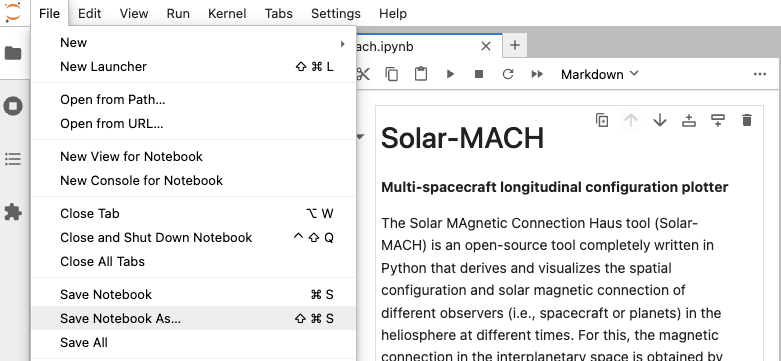


## FAQ

### ModuleNotFoundError: No module named x. 

Please ensure that you have the correct kernel selected for the notebook you are using; although this should in principal happening automatically.
You can find the lists of kernels on the [SERPENTINE](https://serpentine-h2020.eu/hub/) and [SOLER](https://soler-horizon.eu/hub/) websites. 
You can change the kernel by clicking `Kernel` → `Change Kernel...` in the the menu at the top of the notebook. 

### Weird or unclear errors – Cleaning up space

Each user has 5 GB of storage. If this gets full, it can manifest in weird crashes. So if something like this happens, the first thing is to check how much storage you use. 

Every user populates the directory `/home/jovyan/` on their personal copy of the server. Let's check how big it is:

In [1]:
!du -sh /home/jovyan

4.7G	/home/jovyan


If this is close to `5G`, this could cause problems! So let's do some clean up.

First, let's remove duplicate outdated data files. We have a little helper function [remove_duplicate_cdf_files](https://seppy.readthedocs.io/en/latest/api.html#seppy.util.remove_duplicate_cdf_files) for this. It checks in the given directory for files such as `psp_isois-epihi_l2-het-rates60_20240512_v22.cdf` that only differ in their version number in the end. If there are multiple files with the same name that only differ by version number, only the latest version is kept and all others are deleted. The function will print out in the end the files that have been deleted, or just `[]` if there were not duplicates.

In [1]:
from seppy.util import remove_duplicate_cdf_files
# Removing duplicate .cdf files in /home/jovyan/data/
deleted_files = remove_duplicate_cdf_files('/home/jovyan/data/')
print(deleted_files)

Removing duplicate .cdf files in /home/jovyan/data/


  0%|          | 0/374 [00:00<?, ?it/s]

[]


Let's check again the used storage:

In [2]:
!du -sh /home/jovyan

4.7G	/home/jovyan


If this hasn't solved the problem, we have to manually delete some files. 

Let's get a list of the used space per directory (biggest first):

In [3]:
!du -sh /home/jovyan/* | sort -hr

3.3G	/home/jovyan/data
255M	/home/jovyan/soler
122M	/home/jovyan/serpentine-old
89M	/home/jovyan/user-workshop-2022
56M	/home/jovyan/soler_test
33M	/home/jovyan/serpentine
32M	/home/jovyan/sunpy
20M	/home/jovyan/SerPyShock
64K	/home/jovyan/merge_reports
16K	/home/jovyan/lost+found
4.0K	/home/jovyan/merge_report.txt


You can further investigate some of the subdirectories:

In [4]:
!du -sh /home/jovyan/soler/* | sort -hr

101M	/home/jovyan/soler/MSc-course-2025
77M	/home/jovyan/soler/sunkit-spex_demo
70M	/home/jovyan/soler/sep_tools
5.0M	/home/jovyan/soler/shelvis
2.1M	/home/jovyan/soler/NenuFARSolarT3tools
1.6M	/home/jovyan/soler/cider


Delete big files/directories that you do not need anymore or right now, respectively. Remember that the tools will automatically be re-downloaded on server restart, so you can't really break things like that. But of course you have to be careful if you have a modified version of a file that you want to keep!

You can delete files in the File Browser on the left (`View` -> `File Browser`). Or you can do it via shell commands such as `!rm -rf /home/jovyan/folder-to-delete`. Copy this command into a code cell, adjust the folder, and run it. But be aware that this deletes the whole directory without asking for any confirmation!

### How do I get a fresh copy of a file?

If you rename or delete a file, it will be replaced when you next start your notebook server. 

### How do I restart my notebook server?

Go to `File` in the top menu bar and select `Hub Control Panel` (second last entry). This will open a new browser tab/window.
At the very top of this page there will be a red `Stop My Server` button if is running. 
Once stopped, you will see a `Start My Server` button. There may be a short delay depending on available resources. 

### Will my changes to the notebooks be preserved?

We use nbgitpuller to provide the notebooks from GitHub. 
Our changes are merged into your copies each time you start a new notebook server but your changes are preserved in case of a conflict.
See [here](https://nbgitpuller.readthedocs.io/en/latest/topic/automatic-merging.html) for details. 
Best practice is described above. 